<a href="https://colab.research.google.com/github/NandhithaMilkuri/Nandhitha1352ADM/blob/main/Lab10_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA


In [3]:
data = load_iris()
X = data.data[:, :2]
y = (data.target != 0).astype(int)

In [4]:
df = pd.DataFrame(X, columns=data.feature_names[:2])
df['target'] = y

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = LogisticRegression(solver='liblinear', penalty='l1')
model.fit(X_train, y_train)


LogisticRegression(penalty='l1', solver='liblinear')

In [8]:
y_pred = model.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [10]:
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", report)

Accuracy: 1.00
Confusion Matrix:
 [[10  0]
 [ 0 20]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [11]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

In [12]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)


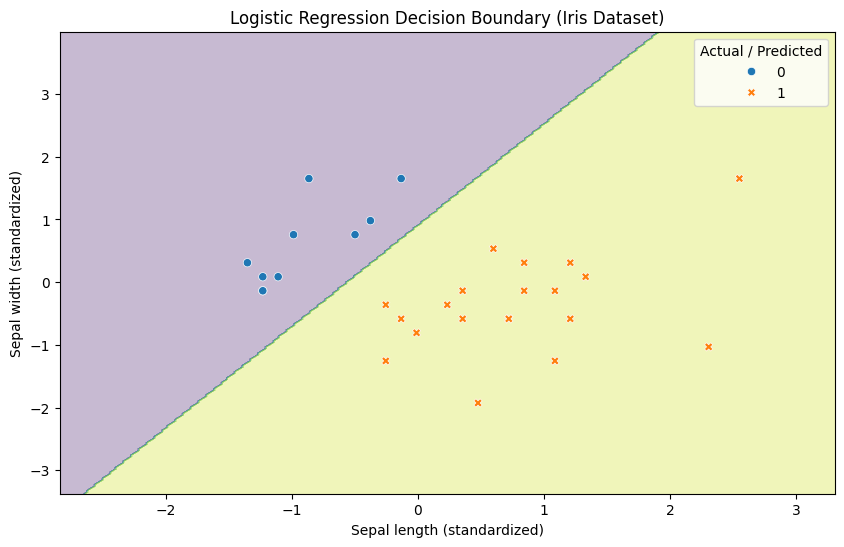

In [13]:
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test, style=y_pred)
plt.title("Logistic Regression Decision Boundary (Iris Dataset)")
plt.xlabel("Sepal length (standardized)")
plt.ylabel("Sepal width (standardized)")
plt.legend(title='Actual / Predicted')
plt.show()